In [153]:
import onep
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
from scipy import stats
import scipy.stats
%matplotlib inline

In [ ]:
animal = 'astro5'
session ='recall'
directory = '/Users/suthardr/Desktop/dCA1_Analysis'

isx = onep.InscopixProcessing(animal,session,directory)
isx.read_inscopix()
traces=isx.get_traces(cell_inds=isx.accepted_inds) #get accepted_cells NxT array of cell activity
timestamps = isx.timestamps.values #get timestamp array (3602 row x 1 col)
z_traces = stats.zscore(traces, axis=1)

In [336]:
animals_cxta = ['astro3', 'astro4']
animals_cxtb = ['astro7', 'astro8']
session ='fc'
directory = '/Users/suthardr/Desktop/dCA1_Analysis'

concat_cxta = np.array([])
for ani in ['astro3','astro4','astro5','astro6']:
    isx = onep.InscopixProcessing(ani,session,directory)
    isx.read_inscopix()
    traces=isx.get_traces(cell_inds=isx.accepted_inds) #get accepted_cells NxT array of cell activity
    concat_cxta = np.concatenate(traces[:, :3601])
print(concat_cxta)
    # timestamps = isx.timestamps.values #get timestamp array (3602 row x 1 col)
    # z_traces = stats.zscore(traces, axis=1)
    # # transposed = z_traces.transpose()
    # concat_cxta = np.concatenate(z_traces[:, :3601], axis=0)

TypeError: only integer scalar arrays can be converted to a scalar index

In [329]:
traces.type()

AttributeError: 'numpy.ndarray' object has no attribute 'type'

In [327]:
concat_cxta

[]

In [210]:
# Run all the helper functions
def bci(data, num_samples, cl=0.95):
    """
    Calculate the confidence interval for each time point in the data using bootstrap method.

    data: 2D numpy array, rows represent samples and columns represent time points.
    num_samples: Number of bootstrap samples.
    cl: Confidence level.

    Returns a 2D numpy array containing the lower and upper bound of the confidence interval for each timepoint.
    """
    n, t = data.shape
    ci = np.zeros((2, t))
    rng = np.random.default_rng()

    bootstrap_array = np.zeros(shape=(num_samples, t))

    for i in range(t):
        # Generate bootstrap samples for the current time point
        rints = rng.integers(0, n, num_samples)
        bootstrap_array[:, i] = data[rints, i]

        sig = 1 - cl
        ci[0, :] = np.percentile(bootstrap_array, q=(sig / 2) * 100, axis=0)
        ci[1, :] = np.percentile(bootstrap_array, q=(1 - (sig / 2)) * 100, axis=0)
    return ci

def tci(array, cl=0.95):
    """_summary_

    Args:
        array (_type_): _description_
        cl (float, optional): _description_. Defaults to 0.95.

    Returns:
        _type_: _description_
        """
    n = array.shape[0]
    crit_t = scipy.stats.t.ppf(cl, df=n - 1)
    c_int = np.zeros(shape=(2, array.shape[1]))
    c_int[0, :] = np.mean(array, axis=0) - (crit_t * scipy.stats.sem(array, axis=0))
    c_int[1, :] = np.mean(array, axis=0) + (crit_t * scipy.stats.sem(array, axis=0))
    return c_int


def eta_significance(ci, sig_duration):

        # find deflections from baseline
        deflections = ci > 0

        # create a sliding window for convolution
        window = np.ones(sig_duration)

        # convolve with boolean array
        true_deflects = np.convolve(deflections, window, 'valid')

        # find start indices where convolution equals to significant_duration
        start_indices = np.where(true_deflects == sig_duration)[0]
        return start_indices

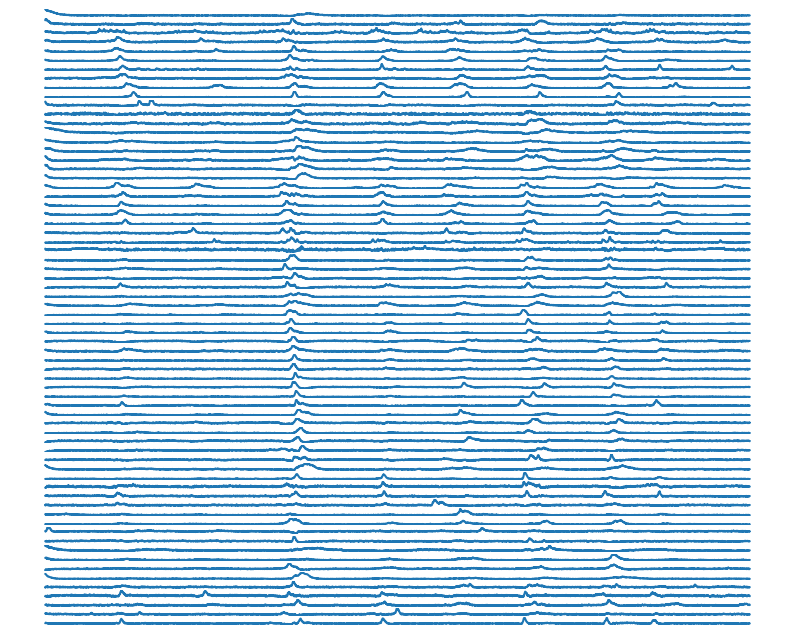

In [175]:
#Plot all cells for desired animal, session
fig, axs = plt.subplots(len(z_traces),1, sharex='col', figsize=(10,8))
for i in range(len(z_traces)):
    axs[i].plot(np.array(z_traces[i,:]))
    axs[i].axis('off')

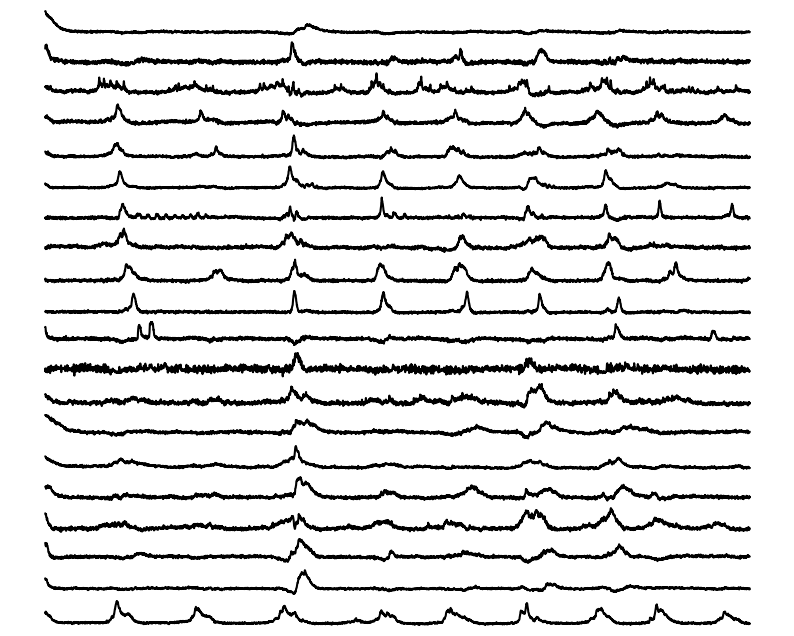

In [3]:
#Plot all cells for desired animal, session
fig, axs = plt.subplots(20,1, sharex='col', figsize=(10,8))
for i in range(20):
    axs[i].plot(np.array(traces[i,:]), color='black')
    axs[i].axis('off')
# plt.plot(np.array(z_traces[19,:]), color='black')
plt.box(False)
plt.xticks(visible=False)
plt.yticks(visible=False)
plt.grid(False)

In [85]:
fig.savefig('/Users/suthardr/Desktop/recall_rep_traces_astro8_10cells.svg')

In [294]:
def shock_eta_all(data, timestamps, events=None, window=10, ci='bci', sig_duration=8, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 7.5)

    def event_interpolation(data, events_):
        interp = scipy.interpolate.interp1d(timestamps, data, kind='cubic')
        within_eta_ = np.zeros((len(events_), number_of_indices))
        for i, event in enumerate(events_):
            time_period = np.linspace(event - (window / 2), event + window, number_of_indices)
            within_eta_[i] = interp(time_period)
        return np.average(within_eta_, axis=0)

    across_eta_ = np.zeros((len(data), number_of_indices))

    # If there's only one event, repeat it for each curve
    if len(events) == 1:
        events = events * len(data)

    for j, curve in enumerate(data):
        across_eta_[j] = event_interpolation(curve, events[j])

    average_trace = np.average(across_eta_, axis=0)

    # choose t-confidence interval or bootstrapped
    if ci == 'tci':
        c_int = tci(across_eta_)
    elif ci == 'bci':
        c_int = bci(across_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    # find significant indices
    start_indices = eta_significance(c_int[0, :], sig_duration=10)  # change to be dependent on the sampling rate

    # make a figure
    if ax is None:
        fig, ax = plt.subplots()
    time = np.linspace(-window / 2, window, number_of_indices)
    ax.plot(time, average_trace, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # plot the significant deflections
    y_height = ax.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        ax.hlines(y=y_height, xmin=time[start_index], xmax=time[end_index], colors='r')

    if ax is None:
        return fig, ax, across_eta_
    else:
        return ax, across_eta_

(<Axes: >,
 array([[-2.37446116e-04, -4.18704494e-04, -1.10794537e-03, ...,
         -1.53058542e-03, -2.85572434e-03, -4.04234855e-03],
        [-3.02420595e-03, -2.95570518e-03, -4.62310403e-03, ...,
         -2.20624339e-04,  3.26698331e-04, -5.33423151e-04],
        [-1.30764551e-03, -6.20296609e-04,  1.55824337e-03, ...,
         -2.01719248e-03, -2.76650802e-03, -2.66996860e-03],
        ...,
        [ 5.77217302e-05, -2.16830395e-03, -1.11150531e-03, ...,
          2.27316931e-03,  9.02208264e-04,  1.66571554e-03],
        [-1.36411273e-03, -2.45275501e-03, -1.12507526e-03, ...,
          1.09349008e-03,  1.79102835e-03,  4.05445540e-03],
        [ 4.24950514e-04, -8.92145775e-04,  1.38645607e-03, ...,
          2.21018391e-03,  5.26146680e-04,  1.58567361e-04]]))

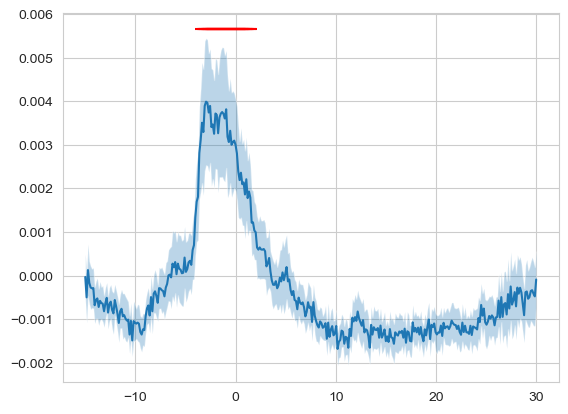

In [302]:
shock_eta_all(data=traces, timestamps=timestamps, events=[[60,120,180,240,300], ], window=30, ci='tci', sig_duration=10)

In [248]:
#One cell at a time
def eta_individual_cells(data, timestamps, events=None, window=10, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 7.5)

    def event_interpolation(data, events_):
        interp = scipy.interpolate.interp1d(timestamps, data, kind='cubic')
        within_eta_ = np.zeros((len(events_), number_of_indices))
        for i, event in enumerate(events_):
            time_period = np.linspace(event - (window / 2), event + window, number_of_indices)
            within_eta_[i] = interp(time_period)
        return np.average(within_eta_, axis=0)

    across_eta_ = np.zeros((len(data), number_of_indices))

    # If there's only one event, repeat it for each curve
    if len(events) == 1:
        events = events * len(data)

    for j, curve in enumerate(data):
        across_eta_[j] = event_interpolation(curve, events[j])

    # make a figure
    if ax is None:
        fig, ax = plt.subplots(len(across_eta_),1, sharex='col', figsize=(4,60))

    time = np.linspace(-window / 2, window, number_of_indices)

    for i in range(len(data)):
        ax[i].plot(time, np.array(across_eta_[i,:]))
        ax[i].grid(False)
        ax[i].spines['top'].set_visible(False)
        ax[i].spines['right'].set_visible(False)
        ax[i].axvline(0, linestyle='--', color='black')
        ax[i].set_ylabel(r'$\frac{dF}{F}$ (%)')
    plt.subplots_adjust(wspace=0.05)
    plt.xlabel('Time(s)')

    if ax is None:
        return fig, ax, across_eta_
    else:
        return ax, across_eta_,

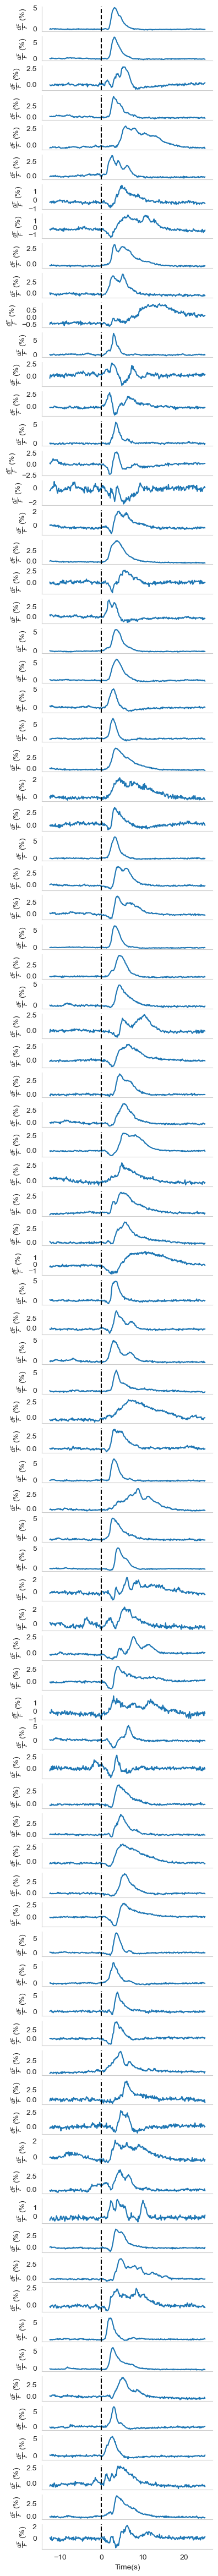

In [249]:
ax, across_eta_ = eta_individual_cells(data=z_traces, timestamps=timestamps, events=[[120,180,240,300], ], window=25)

In [ ]:
np.save('/Users/suthardr/Desktop/astro3.npy', across_eta_)

In [279]:
def single_cell_shock_ci(data, timestamps, events=None, window=10, ci='bci', sig_duration=8, ax=None, **kwargs):
    # window in seconds times 30 indices per second and half the window period to visualize before
    number_of_indices = int(window * 1.5 * 15)

    interp = scipy.interpolate.interp1d(timestamps, data, kind='cubic')
    within_eta_ = np.zeros((len(events), number_of_indices))
    for i, event_ in enumerate(events):
        time_period = np.linspace(event_ - (window / 2), event_ + window, number_of_indices)
        within_eta_[i] = interp(time_period)

    across_eta_ = np.average(within_eta_, axis=0)

    # choose t-confidence interval or bootstrapped
    if ci == 'tci':
        c_int = tci(within_eta_)
    elif ci == 'bci':
        c_int = bci(within_eta_, num_samples=1000)
    else:
        raise ValueError("Confidence interval options are 'tci' or 'bci'")

    time = np.linspace(-window / 2, window, number_of_indices)

    # make a figure
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(time, across_eta_, **kwargs)
    ax.fill_between(time, c_int[0, :], c_int[1, :], alpha=0.3)

    # find significant indices
    start_indices = eta_significance(c_int[0, :], sig_duration) # change to be dependent on the sampling rate

    if len(start_indices) != 0:
        sig = True
    else:
        sig = False

    # plot the significant deflections
    y_height = ax.get_ylim()[1] * 0.97
    for start_index in start_indices:
        end_index = start_index + sig_duration
        ax.hlines(y=y_height, xmin=time[start_index], xmax=time[end_index], colors='r')

    return ax, across_eta_, sig


In [309]:
def plot_all_shock_ci(data): #use z_traces, plots all single cells shock eta + ci to determine 'shock responsive' cells
    list_of_sig = []
    for i in range(len(data)):
        ax, across_eta_, sig = single_cell_shock_ci(data=data[i,:], timestamps=timestamps, events=[120,180,240,300], sig_duration=8, window=15, ci='tci')
        if sig:
            list_of_sig.append(i) #tells you the index of the cells that are shock-responsive
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.axvline(0, linestyle='--', color='black')
    return list_of_sig

/var/folders/5r/7j2h9rcx719_l9q157yrh3nw0000gq/T/ipykernel_25425/378716729.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


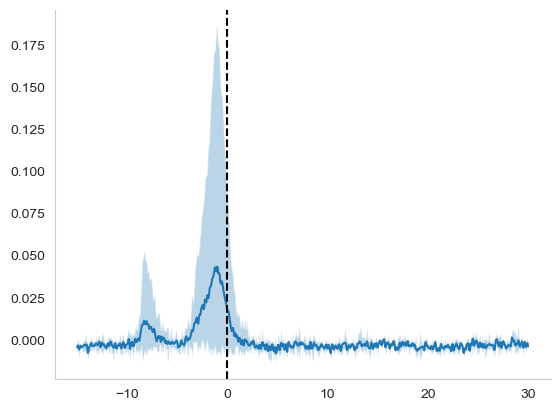

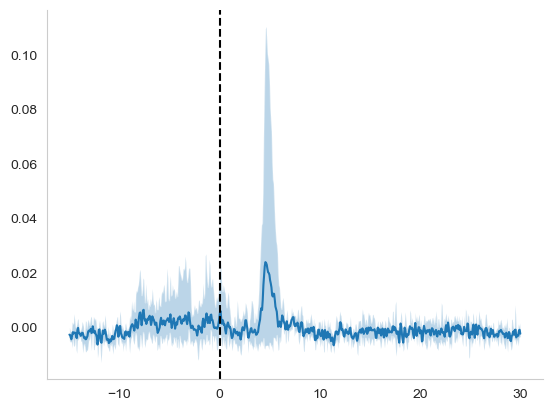

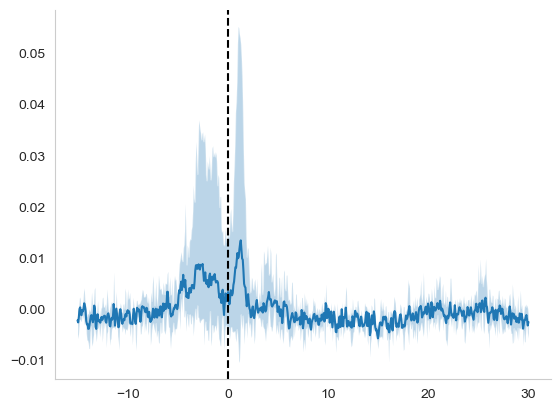

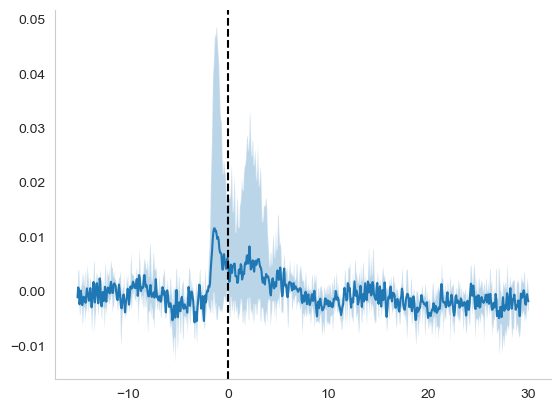

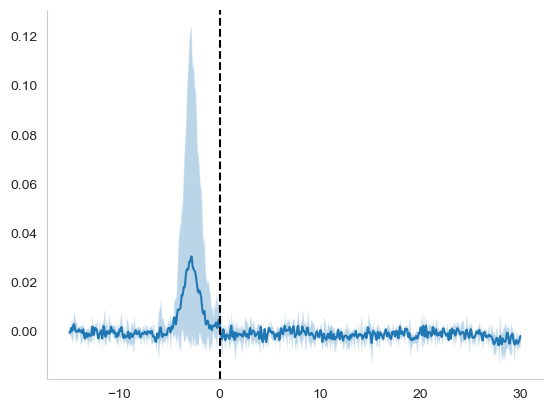

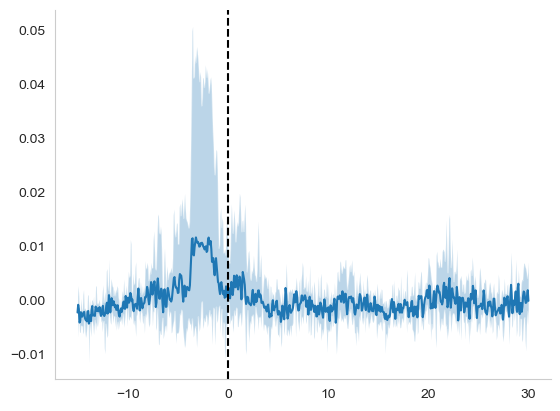

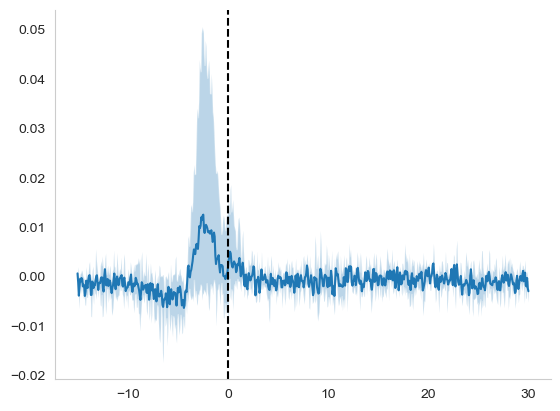

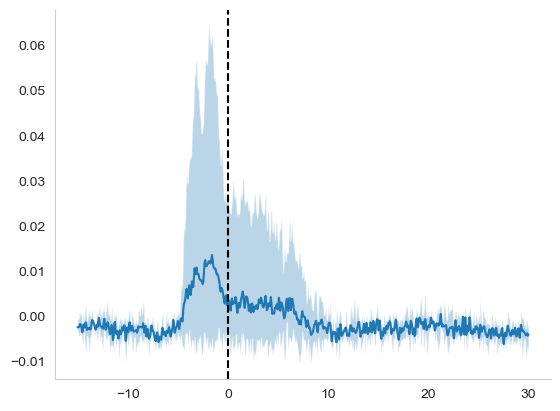

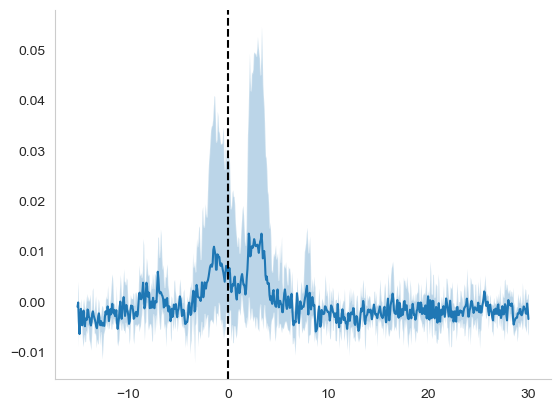

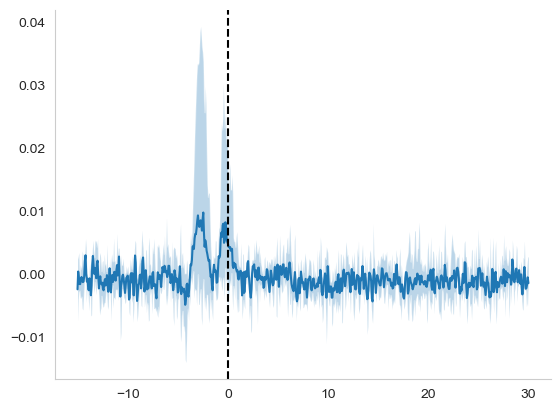

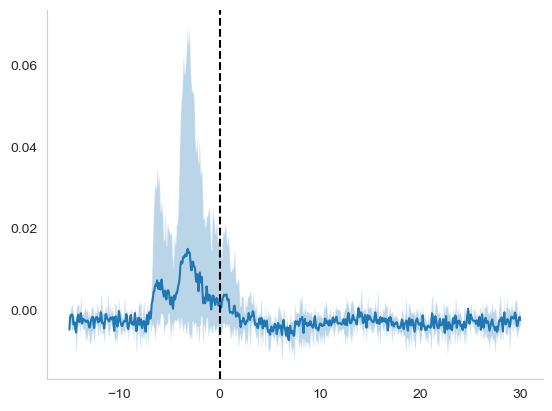

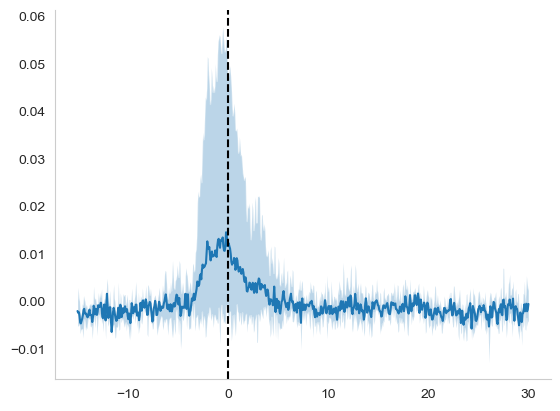

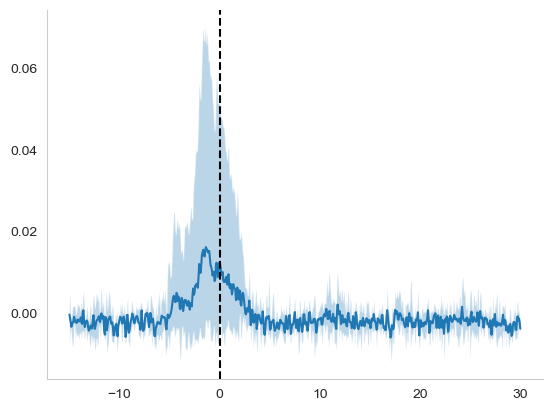

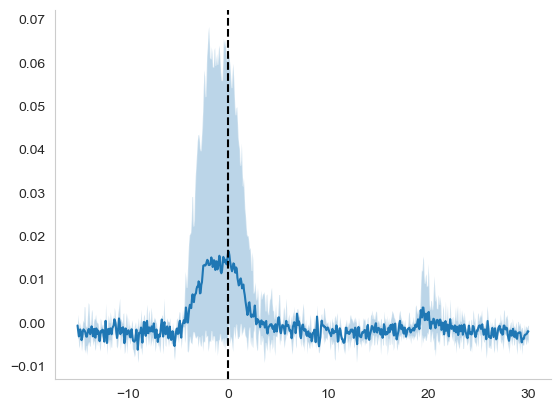

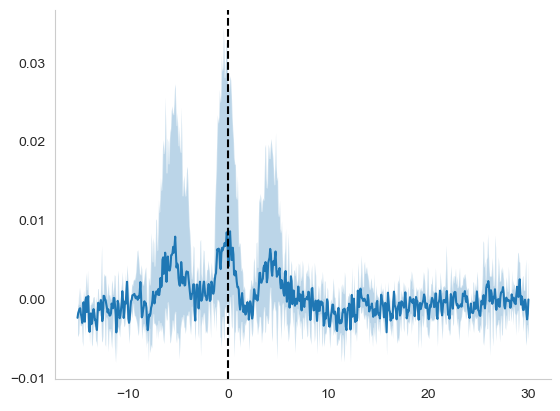

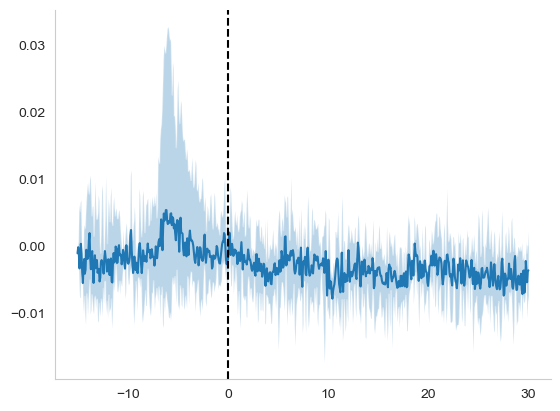

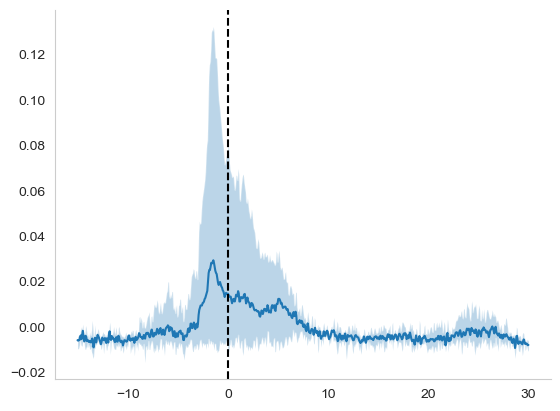

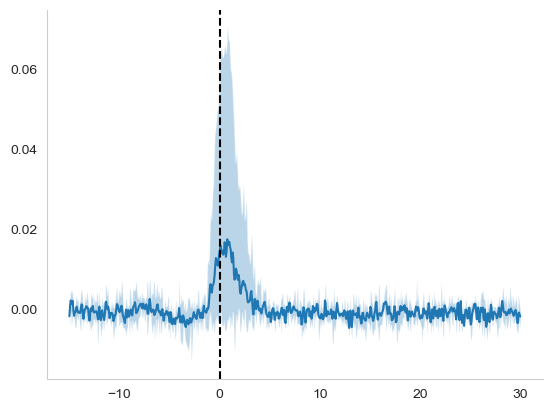

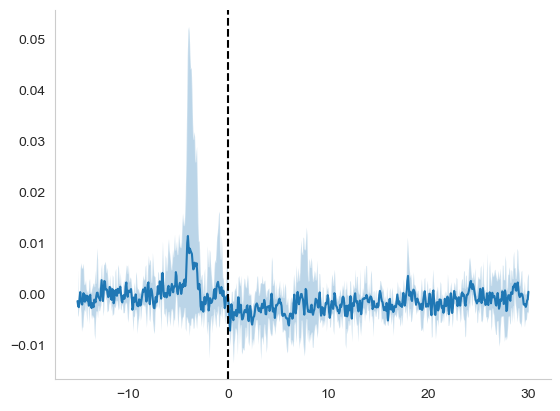

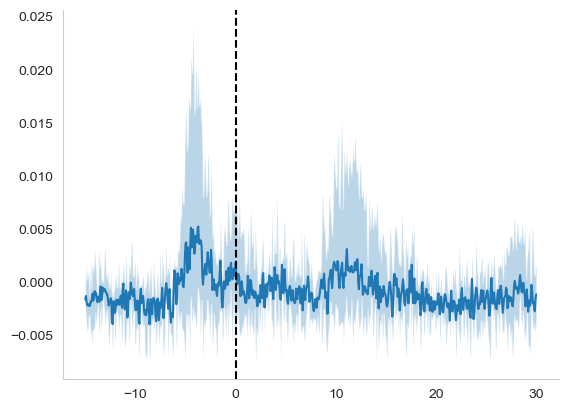

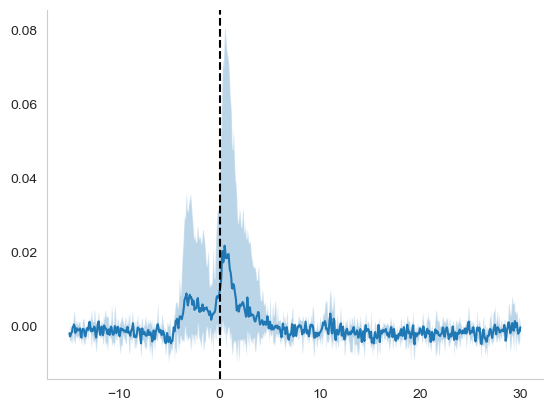

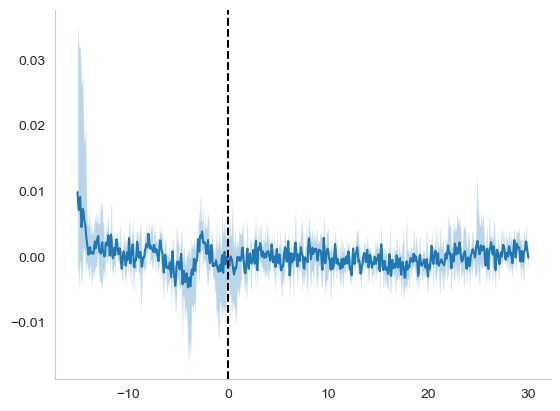

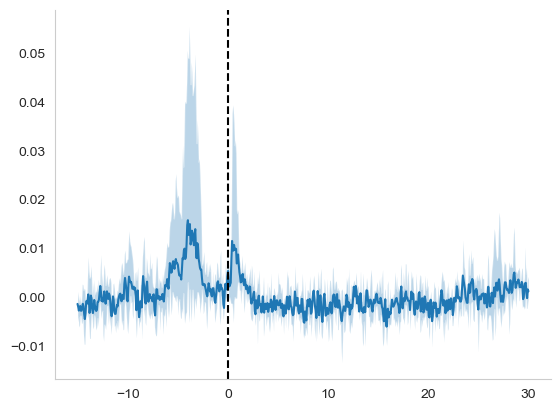

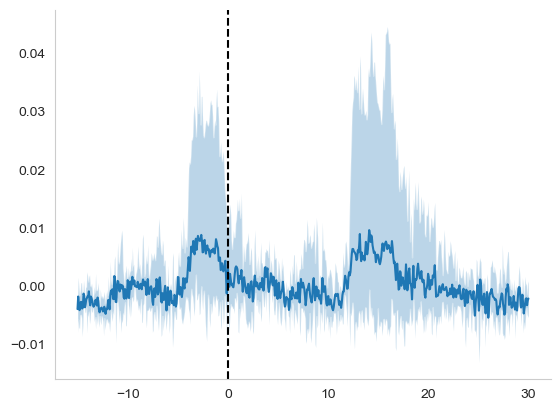

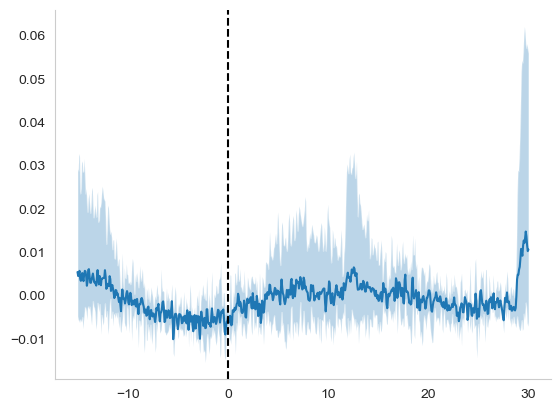

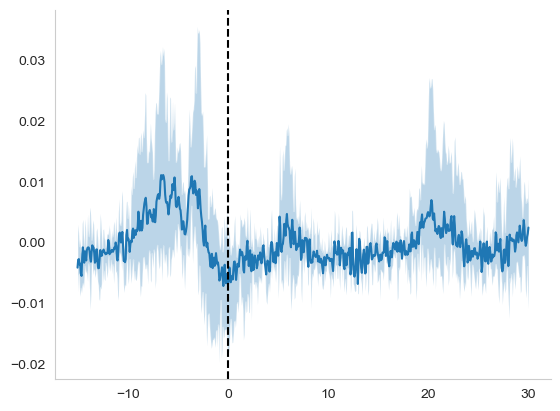

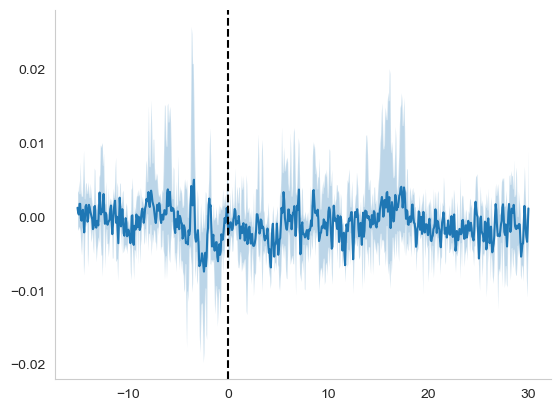

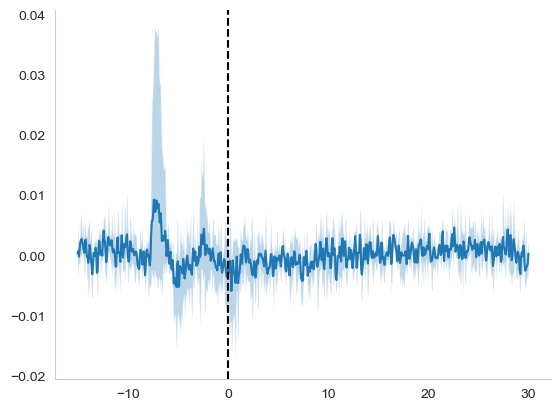

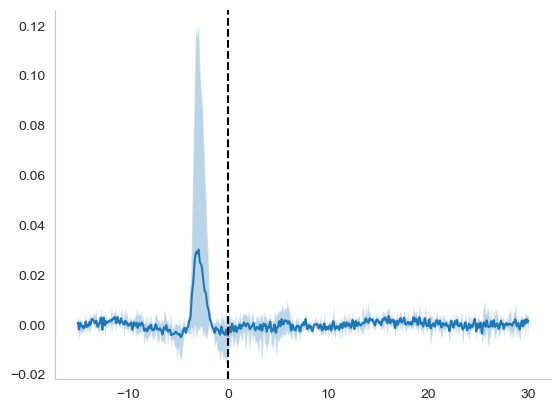

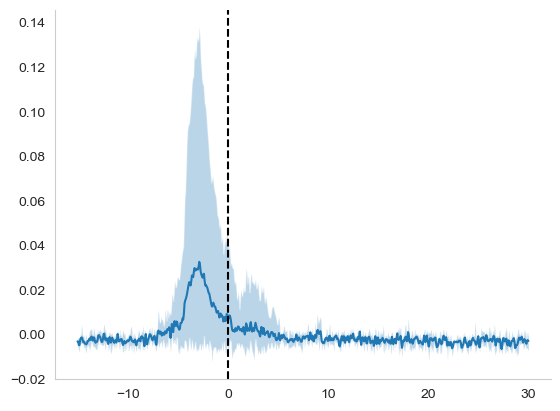

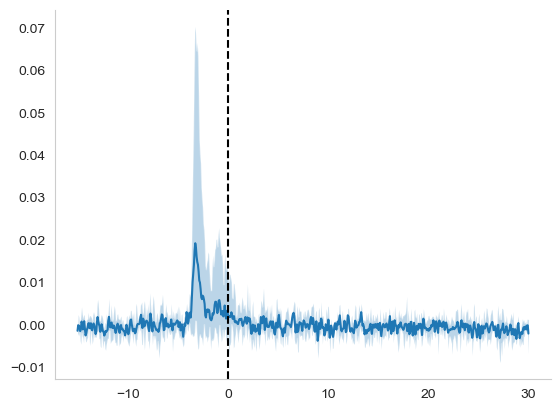

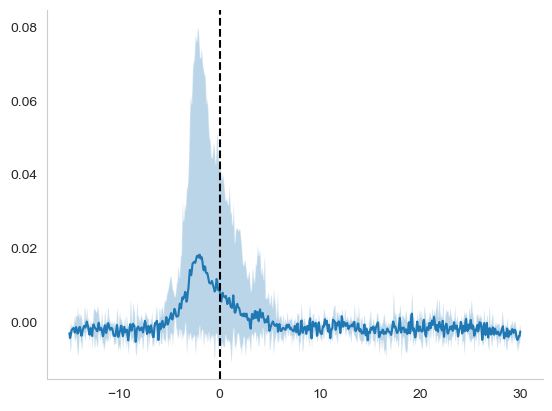

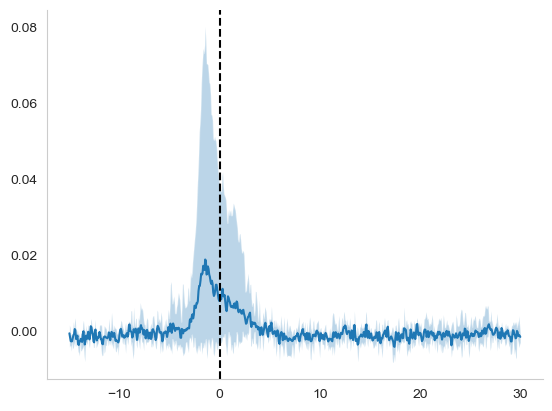

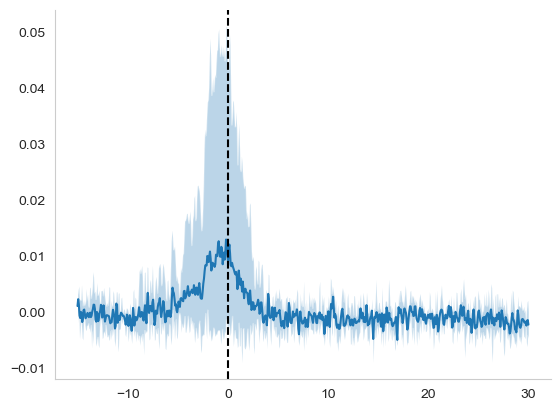

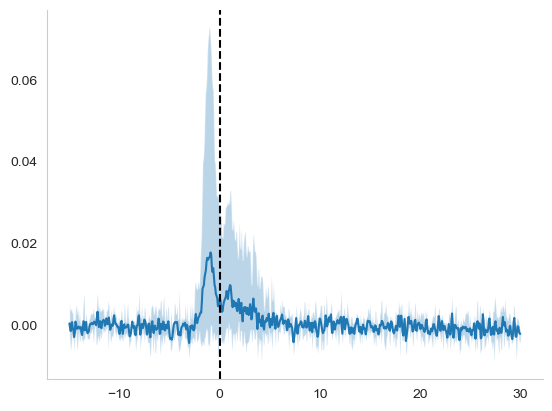

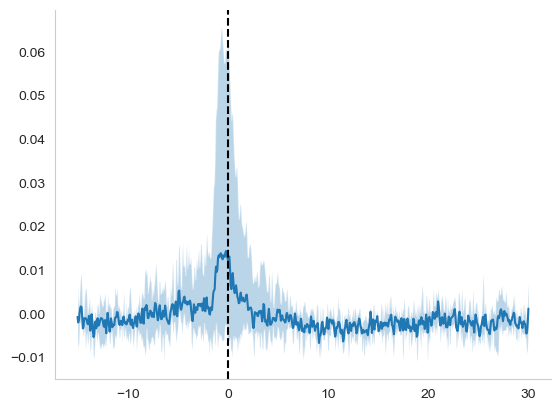

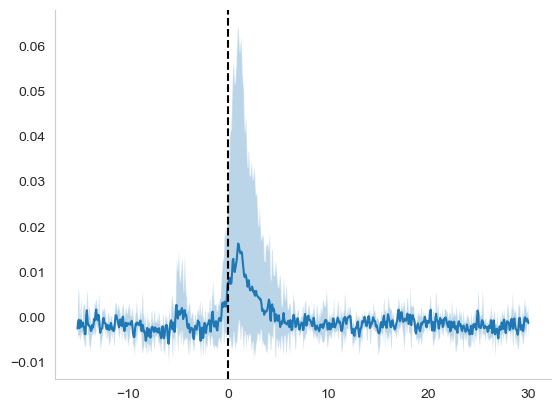

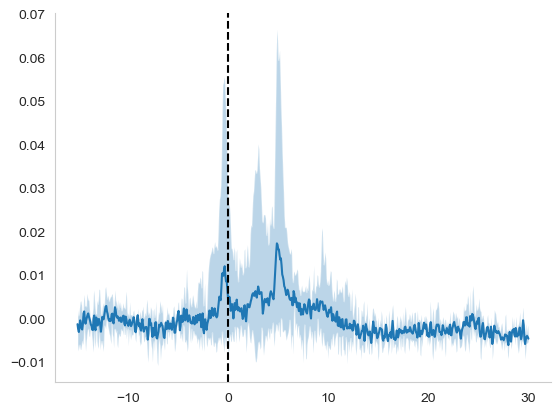

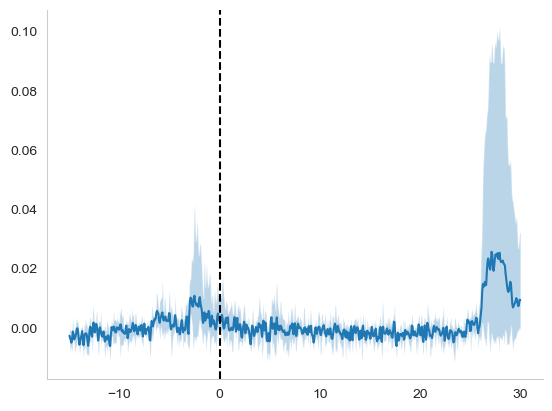

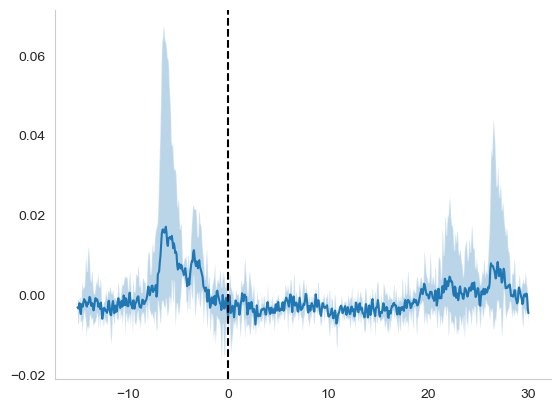

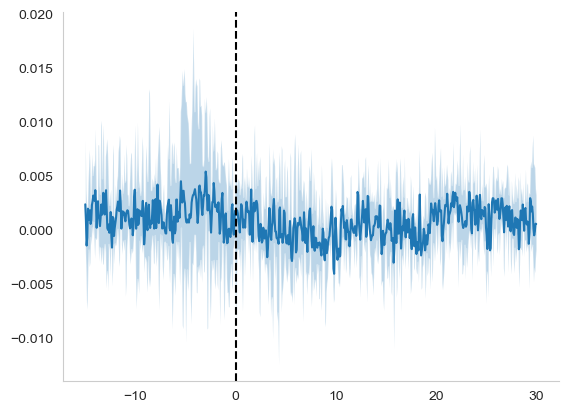

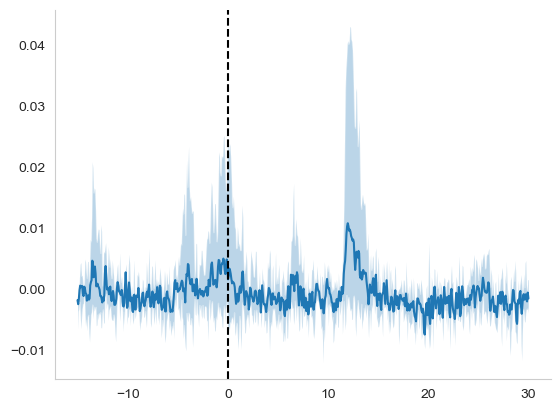

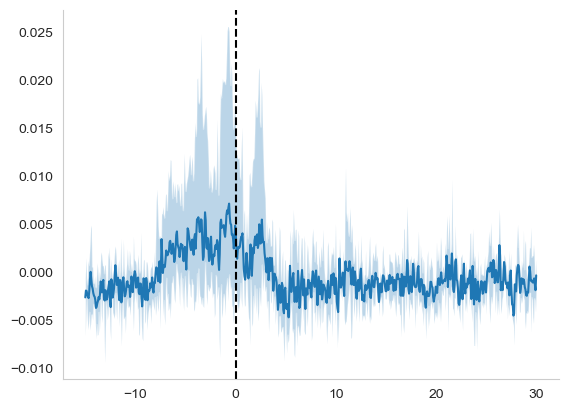

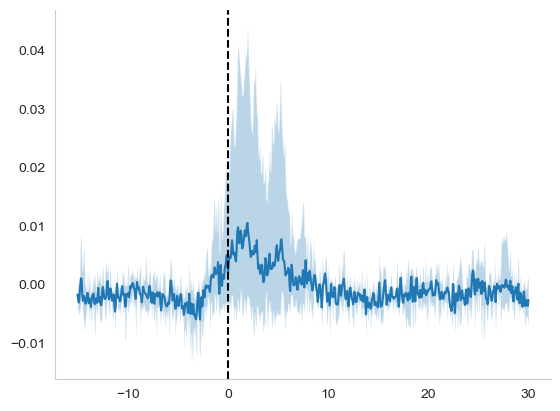

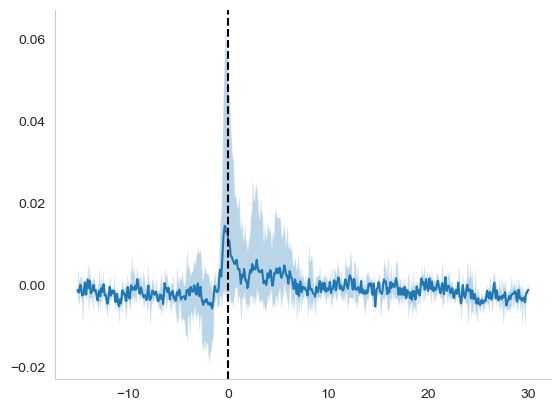

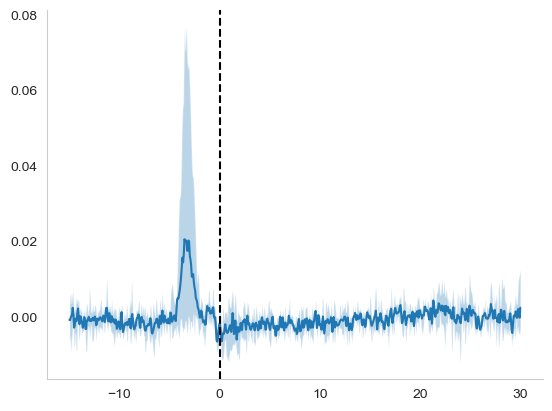

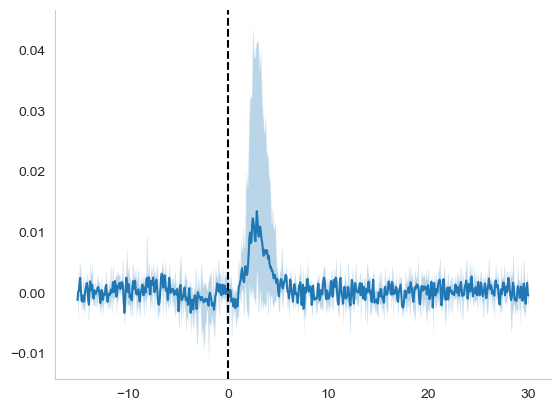

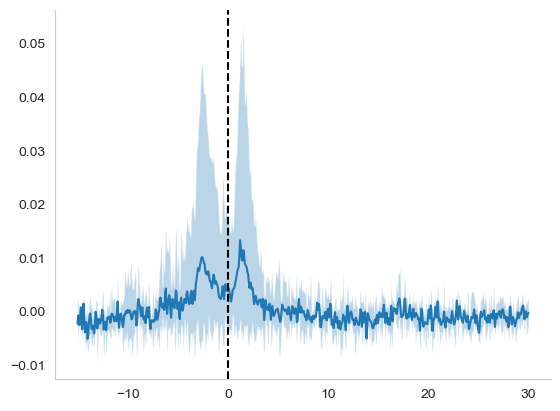

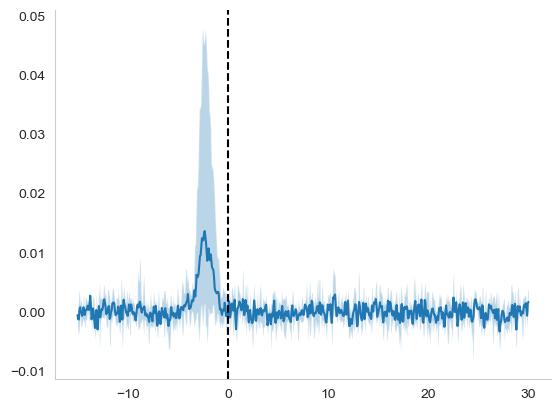

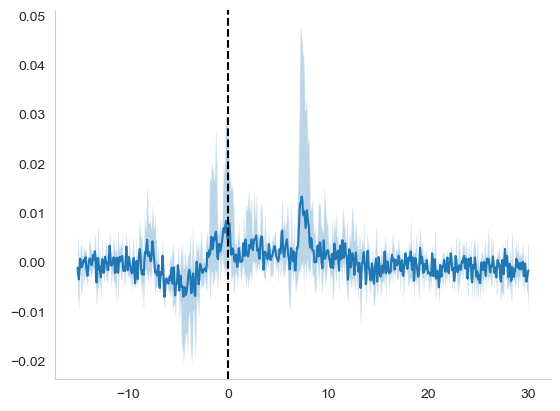

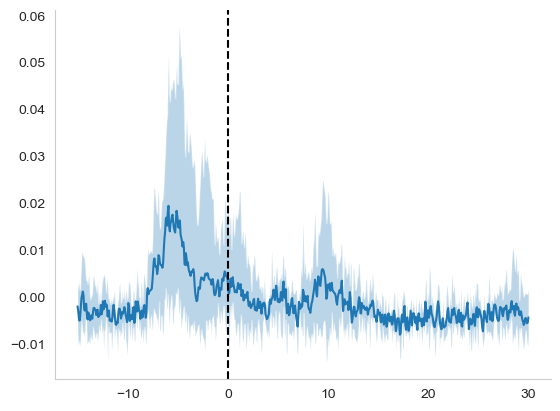

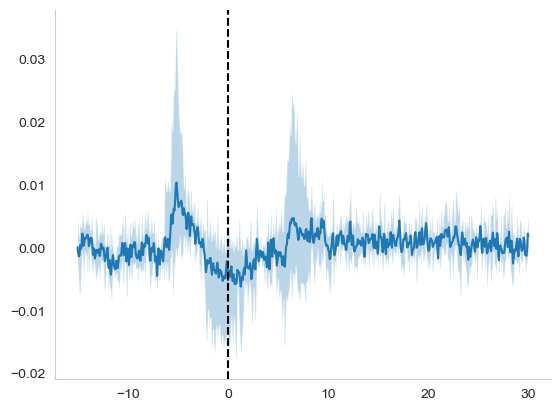

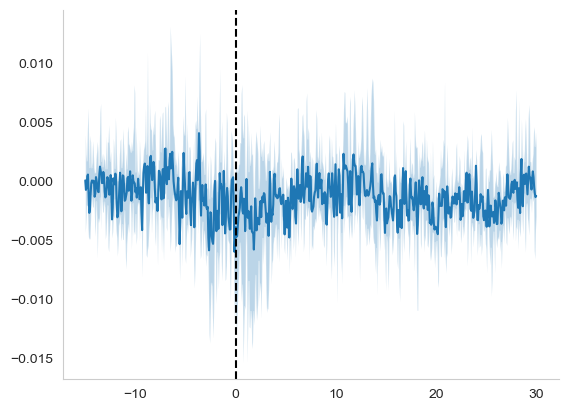

In [308]:
list_of_sig = plot_all_shock_ci(z_cxta)

In [304]:
len(list_of_sig)

0

In [265]:
z_traces

array([[ 4.11282254e+00,  4.93276877e+00,  5.21963355e+00, ...,
        -3.03069262e-01, -2.84276684e-01, -1.63554739e-01],
       [ 4.21642012e+00,  3.86861230e+00,  3.32922262e+00, ...,
        -3.78633349e-01, -5.11294195e-01, -4.35612421e-01],
       [ 9.82942610e+00,  1.01704853e+01,  9.40591116e+00, ...,
         4.11321874e-01, -2.17679234e-01, -1.80573505e-03],
       ...,
       [-6.43535460e-01, -8.71112747e-01, -5.51761456e-01, ...,
        -7.29962442e-01, -3.70865507e-01, -4.52303459e-01],
       [ 5.30725850e-01,  6.45346003e-01,  5.06230887e-01, ...,
        -2.83301083e-01, -7.94023387e-01, -5.66031916e-01],
       [ 2.24559814e-01, -3.26190284e-02,  1.13473169e-02, ...,
         2.41364716e-01, -5.95077031e-01,  5.60488125e-01]])

In [275]:
shock_responsive = z_traces[list_of_sig,:] #do eta multi-event

(<Axes: >,
 array([[-0.25493905, -0.24782085, -0.292563  , ..., -0.31629837,
         -0.25865143, -0.29201806],
        [ 0.09988952,  0.01188878, -0.01716261, ..., -0.37097481,
         -0.44646704, -0.43367532],
        [ 0.13279628,  0.05858477,  0.0292951 , ..., -0.22076416,
         -0.52511417, -0.28305781],
        ...,
        [-0.11367931, -0.40577314, -0.16274678, ..., -0.05225038,
         -0.29289374, -0.39601636],
        [-0.01569415, -0.13033039, -0.21334057, ..., -0.39879387,
         -0.57319679, -0.21315868],
        [-0.08959389, -0.13960934, -0.26858722, ..., -0.14459608,
         -0.10527413, -0.20325605]]))

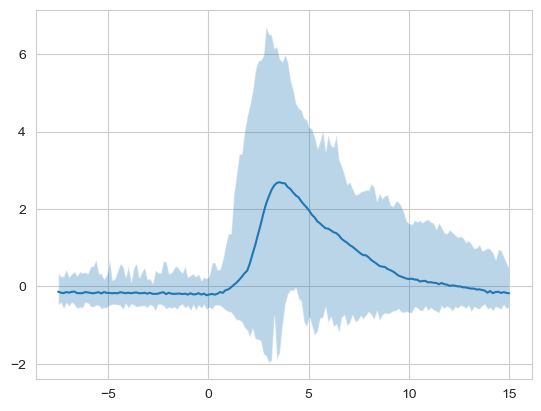

In [277]:
shock_eta_all(data=shock_responsive, timestamps=timestamps, events=[[120,180,240,300], ], window=15, ci='bci', sig_duration=8)